In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [3]:
df = pd.read_csv("emails.csv")
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


In [4]:
df.describe()
df.groupby("spam").describe()
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    df.text,
    df.spam,
    test_size=0.2
)

In [6]:
x_train

5706    Subject: e - mail and voicemail retention poli...
4472    Subject: sfa licenses  iris :  i forwarded the...
2198    Subject: mr . big shot !  vince -  i couldn ' ...
4738    Subject: resumes  karen ,  i have forwarded al...
1394    Subject: re : creditdotcom projects  amitava ,...
                              ...                        
1447    Subject: re : vacation  shirley ,  no problem ...
1919    Subject: re : a visit  dear mr . fujita :  tha...
2238    Subject: re : invoice for energy derivatives c...
2808    Subject: re : resume  sorry , i did not know a...
1383    Subject: status  stinson ,  as you requested ,...
Name: text, Length: 4582, dtype: str

In [7]:
v = CountVectorizer()
x_train_count = v.fit_transform(x_train.values)

In [8]:
x_train_count.toarray()[:3]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 33618))

In [9]:
model = MultinomialNB()
model.fit(x_train_count, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3463.,1119.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.28,-1.41]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 33618)","[[1353., 329., 3.,..., 0., 1., 0.], [ 280., 493., 114.,..., 1., 0., 8.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 33618)","[[ -6.45, -7.86,-12.28,...,-13.66,-12.97,-13.66], [ -6.81, -6.25, -7.71,...,-11.76,-12.45,-10.25]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33618


In [10]:
x_test_count = v.transform(x_test)
model.score(x_test_count, y_test)

0.9895287958115183

In [11]:
predicted = model.predict(x_test_count)
predicted

array([1, 0, 0, ..., 0, 0, 0], shape=(1146,))

In [12]:
y_test

686     1
5241    0
4993    0
2485    0
2301    0
       ..
2233    0
4031    0
4429    0
3963    0
4518    0
Name: spam, Length: 1146, dtype: int64

In [ ]:
cm = confusion_matrix(y_test, predicted)
cm

array([[890,   7],
       [  5, 244]])

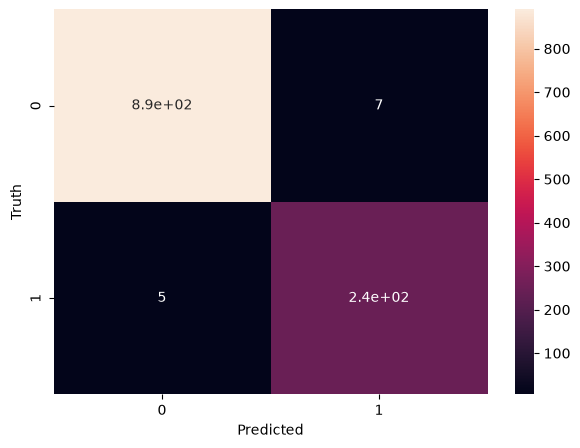

In [15]:
import seaborn as sns
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [16]:
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       897
           1       0.97      0.98      0.98       249

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.98      1146
weighted avg       0.99      0.99      0.99      1146

